# Crossmatch the continuum source catalog with others

Work at 2024 Boston meeting for catalog crossmatching

In [13]:
from astropy.table import Table
from astroquery.vizier import Vizier
from astroquery.simbad import Simbad
from astropy import units as u
from astropy.coordinates import SkyCoord
import pylab as pl

In [6]:
tbl = Table.read('/orange/adamginsburg/ACES/upload/Cont_catalog_stuff/aces_catalog_v2_mv2_ms0.5_mp14_rms0.0001_pb0.0035_pp4_pm2_sm3.fits')

In [7]:
crds = SkyCoord(tbl['GLON'], tbl['GLAT'], unit=(u.deg, u.deg), frame='galactic')

In [10]:
twomass = Vizier.query_region(crds, radius=1*u.arcsec, catalog='II/246/out')[0]

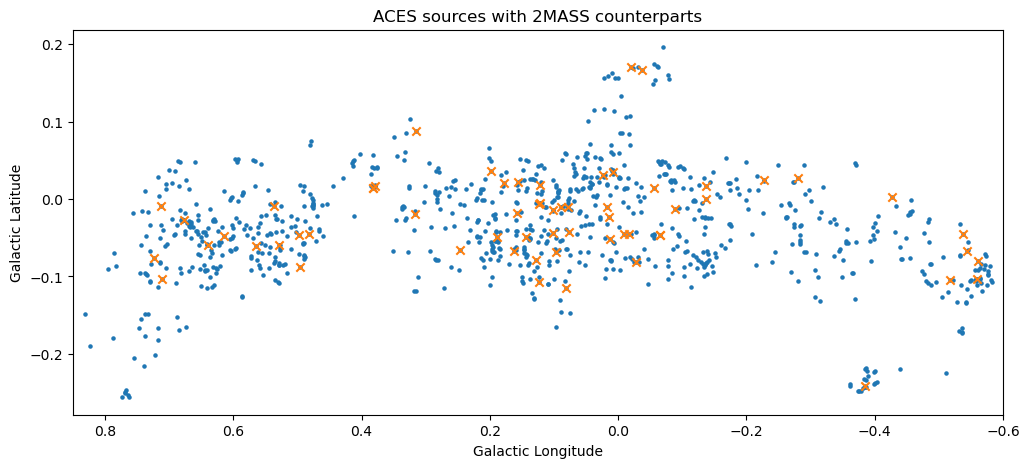

In [38]:
pl.figure(figsize=(12, 5))
pl.scatter(crds.l.wrap_at(180*u.deg), crds.b, s=5)
sel = twomass['_q']
pl.scatter(crds.l.wrap_at(180*u.deg)[sel], crds.b[sel], marker='x')
pl.title("ACES sources with 2MASS counterparts")
pl.xlim(0.85, -0.6)
pl.xlabel('Galactic Longitude')
pl.ylabel('Galactic Latitude');

In [21]:
# this takes a while...
#simbad_matches = Simbad.query_region(crds, radius=1*u.arcsec)

# Eyeball Catalog Crossmatches

In [51]:
import regions

In [52]:
ls /orange/adamginsburg/ACES/upload/Cont_catalog_stuff/eyedentification/

eyedentification_adam.reg  eyedentification_john.reg
eyedentification_jen.reg   eyedentification_michael.reg


In [56]:
adam = regions.Regions.read('/orange/adamginsburg/ACES/upload/Cont_catalog_stuff/eyedentification/eyedentification_adam.reg')
jen = regions.Regions.read('/orange/adamginsburg/ACES/upload/Cont_catalog_stuff/eyedentification/eyedentification_jen.reg')
michael = regions.Regions.read('/orange/adamginsburg/ACES/upload/Cont_catalog_stuff/eyedentification/eyedentification_michael.reg')
john = regions.Regions.read('/orange/adamginsburg/ACES/upload/Cont_catalog_stuff/eyedentification/eyedentification_john.reg')
nazar = regions.Regions.read('/orange/adamginsburg/ACES/upload/Cont_catalog_stuff/eyedentification/eyedentification_nazar.reg')

In [57]:
adam_crds = SkyCoord([(x.center.l, x.center.b) for x in adam], frame=adam[0].center.frame).galactic
jen_crds = SkyCoord([(x.center.l, x.center.b) for x in jen], frame=jen[0].center.frame).galactic
michael_crds = SkyCoord([(x.center.l, x.center.b) for x in michael], frame=michael[0].center.frame).galactic
john_crds = SkyCoord([(x.center.l, x.center.b) for x in john], frame=john[0].center.frame).galactic
nazar_crds = SkyCoord([(x.center.l, x.center.b) for x in nazar], frame=nazar[0].center.frame).galactic

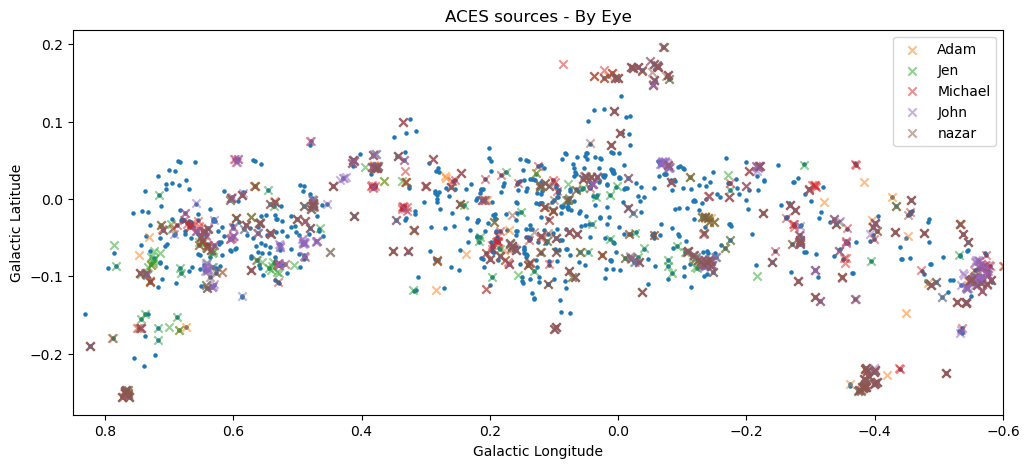

In [58]:
pl.figure(figsize=(12, 5))
pl.scatter(crds.l.wrap_at(180*u.deg), crds.b, s=5)
pl.scatter(adam_crds.l.wrap_at(180*u.deg), adam_crds.b, marker='x', alpha=0.5, label='Adam')
pl.scatter(jen_crds.l.wrap_at(180*u.deg), jen_crds.b, marker='x', alpha=0.5, label='Jen')
pl.scatter(michael_crds.l.wrap_at(180*u.deg), michael_crds.b, marker='x', alpha=0.5, label='Michael')
pl.scatter(john_crds.l.wrap_at(180*u.deg), john_crds.b, marker='x', alpha=0.5, label='John')
pl.scatter(nazar_crds.l.wrap_at(180*u.deg), nazar_crds.b, marker='x', alpha=0.5, label='nazar')
pl.title("ACES sources - By Eye")
pl.xlim(0.85, -0.6)
pl.legend(loc='best')
pl.xlabel('Galactic Longitude')
pl.ylabel('Galactic Latitude');

In [62]:
import numpy as np

In [75]:
ok_all = np.ones(len(adam_crds), dtype='bool')

for match_crds in (jen_crds, michael_crds, john_crds, nazar_crds, ):#crds):
    inds, sep, _ = adam_crds.match_to_catalog_sky(match_crds)
    ok_all &= sep < 3*u.arcsec
    print(ok_all.sum())

165
124
115
101


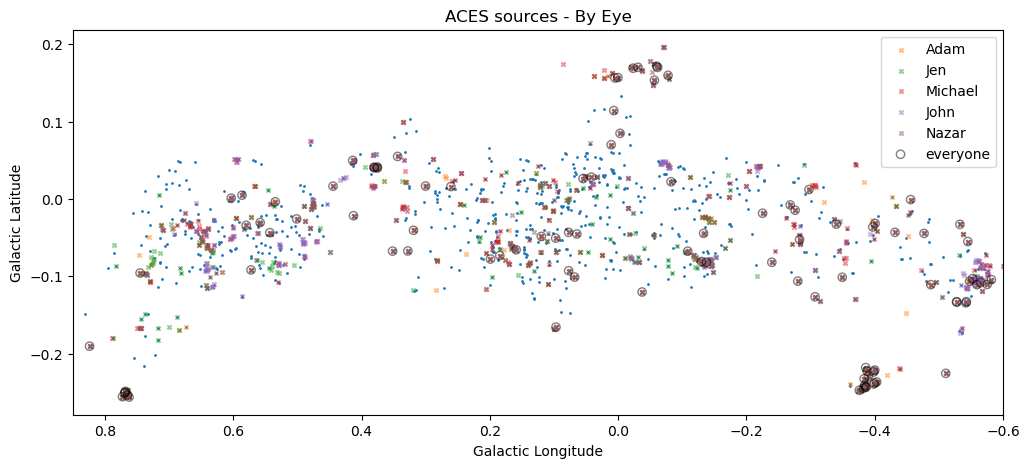

In [73]:
pl.figure(figsize=(12, 5))
pl.scatter(crds.l.wrap_at(180*u.deg), crds.b, s=1)
pl.scatter(adam_crds.l.wrap_at(180*u.deg), adam_crds.b, marker='x', alpha=0.5, label='Adam', s=9)
pl.scatter(jen_crds.l.wrap_at(180*u.deg), jen_crds.b, marker='x', alpha=0.5, label='Jen', s=9)
pl.scatter(michael_crds.l.wrap_at(180*u.deg), michael_crds.b, marker='x', alpha=0.5, label='Michael', s=9)
pl.scatter(john_crds.l.wrap_at(180*u.deg), john_crds.b, marker='x', alpha=0.5, label='John', s=9)
pl.scatter(nazar_crds.l.wrap_at(180*u.deg), nazar_crds.b, marker='x', alpha=0.5, label='Nazar', s=9)

pl.scatter(adam_crds.l.wrap_at(180*u.deg)[ok_all], adam_crds.b[ok_all], marker='o', alpha=0.5, label='everyone',
           facecolor='none', edgecolor='k')
pl.title("ACES sources - By Eye")
pl.xlim(0.85, -0.6)
pl.legend(loc='best')
pl.xlabel('Galactic Longitude')
pl.ylabel('Galactic Latitude');